Activity: flattening the curve
-font size should be larger 
-complicated jargon should be simplified for target audience
-purpose of shading is unclear
-text in image likely won't be detected by a screen reader 

Activity: Alt text
"Two people, one in a lab coat and goggle the other in plain clothes, have a discussion in front of a fume hood"
-descriptive without being presumptive

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests
np.random.seed(613)
x1 = np.arange(50)
y1 = np.random.randint(0, 75,50)
x2 = np.array(["Luffy", "Zoro", "Nami", "Usopp", "Sanji"])
y2 = np.array([110, 180, 240, 99, 220])

/var/folders/ng/3bdnc8gj5_99xshl6405bxwc0000gn/T/ipykernel_22854/1922014529.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


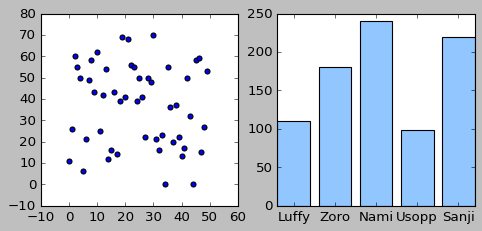

In [52]:
# one figure and one axis
# fig, ax = plt.subplots(figsize=(5, 3))

# establish one figure with two axes 
fig,(ax1, ax2) = plt.subplots(ncols=2,
nrows=1,
figsize=(7, 3))

# plot ax1 (scatterplot) and ax2 (bar)
ax1.scatter(x1,y1)
ax2.bar(x2,y2)
fig.show()

/var/folders/ng/3bdnc8gj5_99xshl6405bxwc0000gn/T/ipykernel_22854/4181949205.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


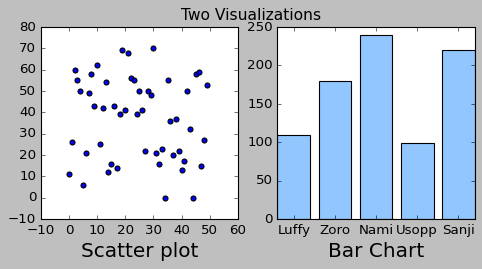

In [58]:
#Activity: Customzing our plots 
plt.style.use('seaborn-v0_8-pastel')

fig,(ax1, ax2) = plt.subplots(ncols=2,
nrows=1,
figsize=(7, 3))

ax1.scatter(x1,y1)
ax1.set_xlabel('Scatter plot', fontsize = 18)
ax2.bar(x2,y2)
ax2.set_xlabel('Bar Chart', fontsize = 18)
fig.suptitle('Two Visualizations', fontsize = 14)
fig.show()

In [59]:
plt.style.use('classic')

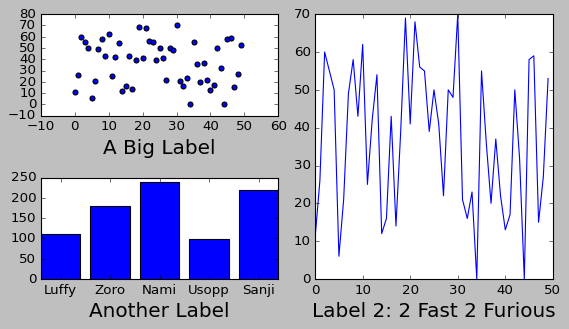

In [60]:
# set up figure with 3 axes for subplots with a constrained layout 
fig, someaxes = plt.subplot_mosaic([['ax1', 'ax3'],
['ax2', 'ax3']],
figsize=(7, 4),
layout = "constrained")

# fill layout with plots
someaxes["ax1"].scatter(x1,y1)
someaxes["ax2"].bar(x2,y2)
someaxes["ax3"].plot(x1,y1)

# label the subplots
someaxes["ax1"].set_xlabel('A Big Label',fontsize=18)
someaxes["ax2"].set_xlabel('Another Label',fontsize=18)
someaxes["ax3"].set_xlabel('Label 2: 2 Fast 2 Furious',fontsize=18 )
plt.show()

<ErrorbarContainer object of 3 artists>

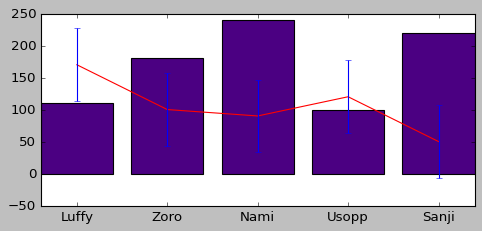

In [61]:
# plotting multiple visualizations on one axis

# calculate standard deviation for y2
y2_sd = np.std(y2)

# first make our sample data
x = np.array(["Luffy", "Zoro", "Nami", "Usopp", "Sanji"])
y1 = np.array([110, 180, 240, 99, 220])
y2 = np.array([170, 100, 90, 120, 50])
# define our figure and axes (just one this time)
fig, ax = plt.subplots(figsize=(7, 3))
# now call both bar and plot elements to the same axes (ax)
ax.bar(x, y1,
color = "indigo")
ax.plot(x, y2,
color = "red")

# add error bars to line
ax.errorbar(x, #our x values
y2, #our y values
yerr = y2_sd,
fmt = "none")

<ErrorbarContainer object of 3 artists>

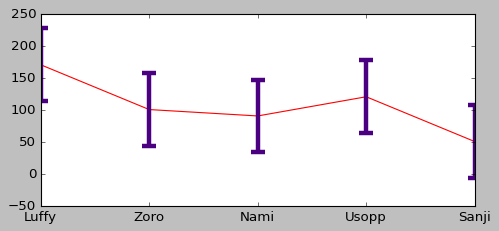

In [62]:
# plot line with custom error bars

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(x, y2,
color = "red")

ax.errorbar(x,
y2,
yerr = y2_sd,
fmt = "none",
ecolor= "indigo",
elinewidth= 4,
capsize = 6,
capthick= 4 )

<ErrorbarContainer object of 3 artists>

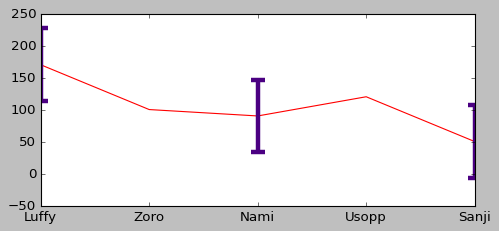

In [63]:
# plot error bars on every second data point

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(x, y2,
color = "red")

ax.errorbar(x,
y2,
yerr = y2_sd,
fmt = "none",
ecolor = "indigo",
elinewidth = 4,
capsize = 6,
capthick = 4,
errorevery= 2 )

In [64]:
# import packages for image uploading

from PIL import Image # to open images
import requests # to get images from URLs
from io import BytesIO # to store images

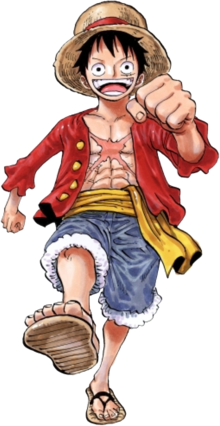

In [65]:
# load image from url
url = "https://upload.wikimedia.org/wikipedia/en/c/cb/Monkey_D_Luffy.png"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)
response.raise_for_status()

image = Image.open(BytesIO(response.content))
image

(np.float64(-0.5), np.float64(219.5), np.float64(425.5), np.float64(-0.5))

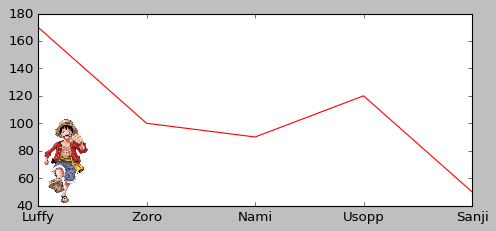

In [66]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(x, y2, color = "red")

ax_image = fig.add_axes([0.1, # x coordinate (ON FIGURE, NOT AXES)
0.11, # y coordinate (ON FIGURE, NOT AXES)
0.15, # image width
0.35]) # image height

ax_image.imshow(image)
ax_image.axis('off')

In [67]:
path = '/Users/corymckenzie/Desktop/visualization/02_activities/assignments/participation'
# can be full path or relative path
filename = '/test_fig.png'

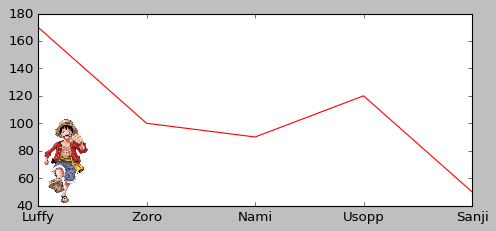

In [69]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(x, y2, color = "red")

ax_image = fig.add_axes([0.1, # x coordinate (ON FIGURE, NOT AXES)
0.11, # y coordinate (ON FIGURE, NOT AXES)
0.15, # image width
0.35]) # image height

ax_image.imshow(image)
ax_image.axis('off')

plt.savefig(path+filename, dpi=300)
# note that path shouldn't end with / since filename starts with it